# Governança de TI e Memória Institucional na Administração Pública

## Sobre esta análise

Este notebook documenta a etapa de **coleta, tratamento e análise exploratória de dados** que conduzi de forma independente como parte de um Projeto Integrador em grupo, cujo objetivo geral era propor a continuidade de um portal de gestão do conhecimento (SIGESPRO) para uma Coordenadoria de TI municipal.

O papel desta análise dentro do projeto foi **fundamentar, com dados públicos, o problema que a proposta pretende resolver**: a fragmentação do conhecimento técnico e a ausência de instrumentos formais de governança de TI na gestão pública brasileira.

Para isso, trabalhei com duas fontes de dados distintas:

1. **Governança de TI em prefeituras brasileiras** — dados da pesquisa TIC Governo Eletrônico (Cetic.br, 2023), para entender o cenário nacional.  
*Dados disponíveis em: https://cetic.br/pt/pesquisa/governo-eletronico/.  
Acesso em: 16.mar.2026.*  

2. **Orçamento de TI da Prefeitura de São Paulo (2025)** — dados orçamentários públicos, para entender como uma prefeitura de grande porte aloca recursos entre manutenção e desenvolvimento de novos sistemas.  
*Dados disponíveis em: https://orcamento.sf.prefeitura.sp.gov.br/orcamento/execucao.php  
Acesso em 17.mar.2026*  


**Perguntas que guiaram a análise:**  
- Como a gestão pública gere a governança em TI?
- Existe uma correlação entre porte do município (ou localização) e a adoção de planos formais de governança de TI (PDTI/PSI)?
- Na prática orçamentária de uma grande prefeitura, o investimento em TI prioriza manter sistemas existentes ou criar novos?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Dados de governança em TI das prefeituras brasileiras

In [ ]:
df = pd.read_excel('/content/Planilha_formatada_pandas.xlsx')
df

,Grande_Grupo,Subgrupo,PETI_Sim,PETI_Nao,PETI_Nao_Sabe,PETI_Nao_Resp,Seguranca_Sim,Seguranca_Nao,Seguranca_Nao_Sabe,Seguranca_Nao_Resp
0,TOTAL,Total,28,61,11,0,32,56,12,0
1,LOCALIZAÇÃO,Capital,66,30,4,0,66,30,5,0
2,LOCALIZAÇÃO,Interior,28,61,11,0,32,56,12,0
3,REGIÃO,Norte,24,64,11,1,28,59,12,0
4,REGIÃO,Nordeste,24,66,10,0,24,63,13,0
5,REGIÃO,Sudeste,33,56,10,0,38,50,12,0
6,REGIÃO,Sul,26,63,10,0,32,57,11,0
7,REGIÃO,Centro-Oeste,30,55,14,0,33,53,14,0
8,PORTE,Até 10 mil hab,21,69,11,0,26,61,13,0
9,PORTE,10 mil a 100 mil hab,27,61,12,0,31,57,13,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Grande_Grupo        12 non-null     object
 1   Subgrupo            12 non-null     object
 2   PETI_Sim            12 non-null     int64 
 3   PETI_Nao            12 non-null     int64 
 4   PETI_Nao_Sabe       12 non-null     int64 
 5   PETI_Nao_Resp       12 non-null     int64 
 6   Seguranca_Sim       12 non-null     int64 
 7   Seguranca_Nao       12 non-null     int64 
 8   Seguranca_Nao_Sabe  12 non-null     int64 
 9   Seguranca_Nao_Resp  12 non-null     int64 
dtypes: int64(8), object(2)
memory usage: 1.1+ KB


In [ ]:
df_localizacao = df[df['Subgrupo'].isin(['Capital', 'Interior'])].copy()
df_localizacao

,Grande_Grupo,Subgrupo,PETI_Sim,PETI_Nao,PETI_Nao_Sabe,PETI_Nao_Resp,Seguranca_Sim,Seguranca_Nao,Seguranca_Nao_Sabe,Seguranca_Nao_Resp
1,LOCALIZAÇÃO,Capital,66,30,4,0,66,30,5,0
2,LOCALIZAÇÃO,Interior,28,61,11,0,32,56,12,0


In [ ]:
#Separando os dados de PDTI e Segurança (sim) e transformando em uma tabela 'longa'
plot_localizacao = df_localizacao.melt(
    id_vars='Subgrupo',
    value_vars=['PETI_Sim', 'Seguranca_Sim'],
    var_name='Documento',
    value_name='Percentual'
)
plot_localizacao

,Subgrupo,Documento,Percentual
0,Capital,PETI_Sim,66
1,Interior,PETI_Sim,28
2,Capital,Seguranca_Sim,66
3,Interior,Seguranca_Sim,32


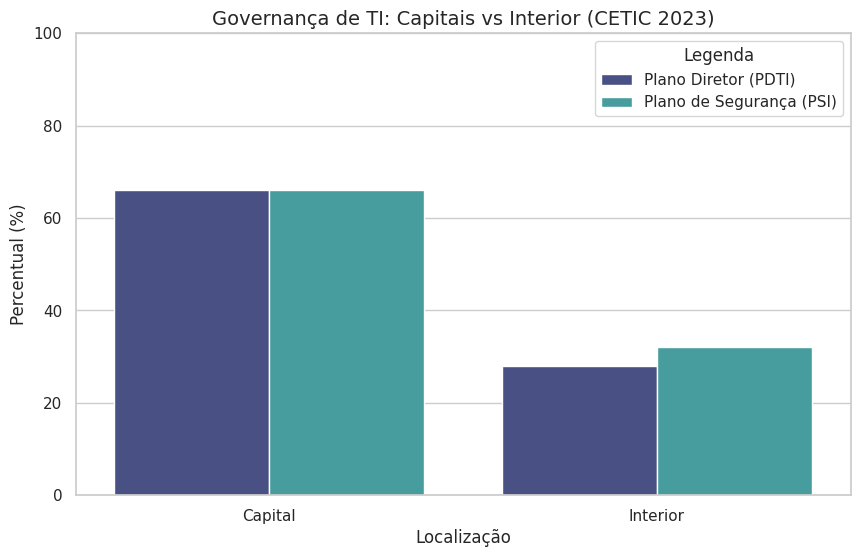

In [ ]:
# Criando a visualização
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data= plot_localizacao, x='Subgrupo', y='Percentual', hue='Documento', palette='mako')
plt.title('Governança de TI: Capitais vs Interior (CETIC 2023)', fontsize=14)
plt.ylabel('Percentual (%)')
plt.xlabel('Localização')
plt.ylim(0, 100)
handles, labels = ax.get_legend_handles_labels() #Pegando a legenda original. Handles são os marcadores com a cor, labels são o texto
ax.legend(handles, ['Plano Diretor (PDTI)', 'Plano de Segurança (PSI)'], title='Legenda') #Sobrescrevendo a legenda
plt.show()

In [ ]:
df_porte=df[df['Grande_Grupo']=='PORTE'].copy()
df_porte

,Grande_Grupo,Subgrupo,PETI_Sim,PETI_Nao,PETI_Nao_Sabe,PETI_Nao_Resp,Seguranca_Sim,Seguranca_Nao,Seguranca_Nao_Sabe,Seguranca_Nao_Resp
8,PORTE,Até 10 mil hab,21,69,11,0,26,61,13,0
9,PORTE,10 mil a 100 mil hab,27,61,12,0,31,57,13,0
10,PORTE,100 mil a 500 mil hab,49,45,5,0,49,43,8,0
11,PORTE,Mais de 500 mil hab,70,20,9,0,71,19,10,0


In [ ]:
#Separando os dados de PDTI e Segurança (sim) e transformando em uma tabela 'longa'
plot_porte = df_porte.melt(
  id_vars='Subgrupo',
  value_vars=['PETI_Sim', 'Seguranca_Sim'] ,
  var_name='Documento',
  value_name='Percentual'
)

plot_porte

,Subgrupo,Documento,Percentual
0,Até 10 mil hab,PETI_Sim,21
1,10 mil a 100 mil hab,PETI_Sim,27
2,100 mil a 500 mil hab,PETI_Sim,49
3,Mais de 500 mil hab,PETI_Sim,70
4,Até 10 mil hab,Seguranca_Sim,26
5,10 mil a 100 mil hab,Seguranca_Sim,31
6,100 mil a 500 mil hab,Seguranca_Sim,49
7,Mais de 500 mil hab,Seguranca_Sim,71


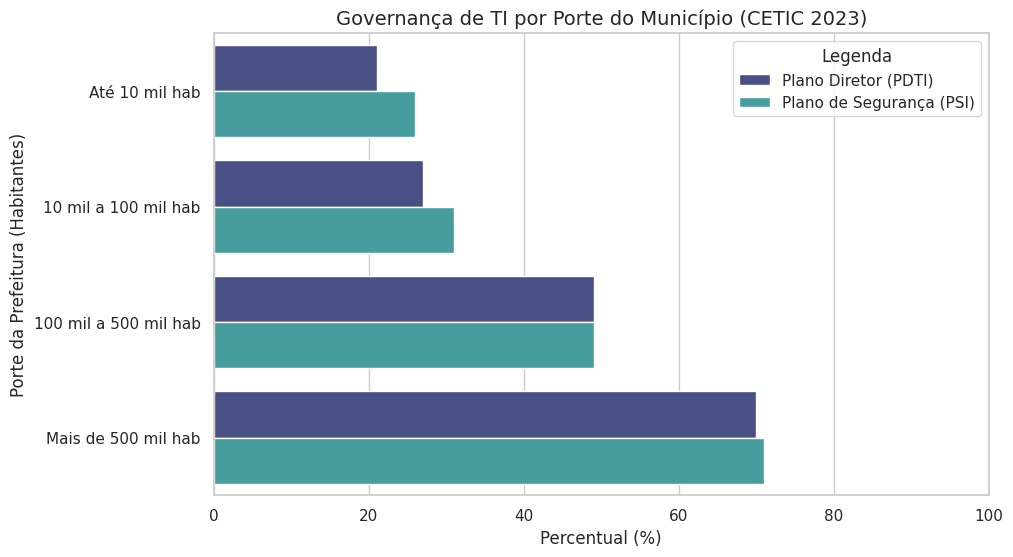

In [ ]:
# Criando a visualização
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data= plot_porte, x='Percentual', y='Subgrupo', hue='Documento', palette='mako')
plt.title('Governança de TI por Porte do Município (CETIC 2023)', fontsize=14)
plt.xlabel('Percentual (%)')
plt.ylabel('Porte da Prefeitura (Habitantes)')
plt.xlim(0,100)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Plano Diretor (PDTI)', 'Plano de Segurança (PSI)'], title='Legenda')
plt.show()

**O que os gráficos acima mostram:** há uma diferença expressiva entre capitais e municípios do interior na adoção de planos formais de TI (66% das capitais possuem PDTI, contra apenas 28% no interior), e essa adoção cresce de forma consistente com o porte populacional do município. Apesar disso, cerca de 30% das administrações de grande porte (acima de 500 mil habitantes) ainda não possuem planejamento formal de TI. Isso confirma que a lacuna de governança não é um problema pontual, mas estrutural e distribuído de forma desigual pelo país.

### Dados de investimentos em TI da prefeitura da cidade de SP

In [ ]:
df = pd.read_excel('/content/Base de Dados Orçamentária da cidade de SP.xlsx')
df

,Cd_Exercicio,Cd_AnoExecucao,Administracao,Cd_Orgao,Sigla_Orgao,Ds_Orgao,Cd_Unidade,Ds_Unidade,Cd_Funcao,Ds_Funcao,...,Vl_Orcado_Atualizado,Vl_Congelado,Vl_Descongelado,Vl_CongeladoLiquido,Disponivel,Vl_ReservadoLiquido,Vl_EmpenhadoLiquido,Vl_Liquidado,Vl_Pago,Saldo_Dotacao
0,2025,2025,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,...,0.00,1000.00,1000.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00
1,2025,2025,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,...,333788.69,810081.41,810081.41,0.0,333788.69,332694.26,332694.26,322334.65,322334.65,1094.43
2,2025,2025,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,...,194491.13,73185.43,73185.43,0.0,194491.13,189690.93,189690.93,150015.95,150015.95,4800.20
3,2025,2025,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,...,565331.80,411675.15,411675.15,0.0,565331.80,565331.80,565331.80,557414.50,557414.50,0.00
4,2025,2025,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,...,9730731.73,0.00,0.00,0.0,9730731.73,9730731.73,9730731.73,6450837.28,6450837.28,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,2025,2025,Legislativo,9,CMSP,Câmara Municipal de São Paulo,10,Câmara Municipal de São Paulo,1,Legislativa,...,12237391.00,8305000.00,8305000.00,0.0,12237391.00,11894783.45,11894783.45,10016422.94,9927355.16,342607.55
281,2025,2025,Legislativo,10,TCMSP,Tribunal de Contas do Município de São Paulo,10,Tribunal de Contas do Município de São Paulo,1,Legislativa,...,6400000.00,0.00,0.00,0.0,6400000.00,6378757.70,6378757.70,3535542.91,3535542.91,21242.30
282,2025,2025,Legislativo,10,TCMSP,Tribunal de Contas do Município de São Paulo,10,Tribunal de Contas do Município de São Paulo,1,Legislativa,...,4375000.00,0.00,0.00,0.0,4375000.00,4279759.70,4279759.70,2651166.22,2605668.60,95240.30
283,2025,2025,Legislativo,10,TCMSP,Tribunal de Contas do Município de São Paulo,10,Tribunal de Contas do Município de São Paulo,1,Legislativa,...,215604.00,0.00,0.00,0.0,215604.00,8900.42,8900.42,7307.46,7307.46,206703.58


In [ ]:
'''
verificando colunas cujos os valores dos campos são únicos
O objetivo é identificar colunas que têm apenas um tipo de valor (ou seja, são sempre as mesmas).
Cd_Exercicio = 2025
Cd_AnoExecucao = 2025
Cd_SubFuncao = 126
Ds_SubFuncao = Tecnologia da Informação
Ds_Despesa = Serviços de Tecnologia da Informação e Comunicação - Pessoa Jurídica
Ds_Modalidade = Aplicações Diretas
'''
df.nunique()

,0
Cd_Exercicio,1
Cd_AnoExecucao,1
Administracao,3
Cd_Orgao,72
Sigla_Orgao,72
Ds_Orgao,72
Cd_Unidade,4
Ds_Unidade,27
Cd_Funcao,17
Ds_Funcao,17


In [ ]:
#deletando colunas com valores unicos
df = df.drop(columns=['Cd_Exercicio', 'Cd_AnoExecucao', 'Cd_SubFuncao', 'Ds_SubFuncao', 'Ds_Despesa', 'Ds_Modalidade'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Administracao           285 non-null    object 
 1   Cd_Orgao                285 non-null    int64  
 2   Sigla_Orgao             285 non-null    object 
 3   Ds_Orgao                285 non-null    object 
 4   Cd_Unidade              285 non-null    int64  
 5   Ds_Unidade              285 non-null    object 
 6   Cd_Funcao               285 non-null    int64  
 7   Ds_Funcao               285 non-null    object 
 8   Cd_Programa             285 non-null    int64  
 9   Ds_Programa             285 non-null    object 
 10  PA                      285 non-null    object 
 11  PAPA                    285 non-null    object 
 12  ProjetoAtividade        285 non-null    int64  
 13  Ds_Projeto_Atividade    285 non-null    object 
 14  Ds_Categoria            285 non-null    ob

In [ ]:
#verificando quais são os projetos e atividades planejadas no orçamento
df['Ds_Projeto_Atividade'].value_counts()

,count
Ds_Projeto_Atividade,
"Aquisição de Materiais, Equipamentos e Serviços de Informação e Comunicação",144
Manutenção e Operação de Sistemas de Informação e Comunicação,86
Desenvolvimento de Sistemas de Informação e Comunicação,41
Manutenção e Operação de Redes de Monitoramento Remoto para Segurança Urbana,4
Construção e Implantação do Descomplica SP,2
Operação e Manutenção do Portal da PMSP_x000D_,2
Manutenção e Operação do Descomplica SP,2
"BID II - Ampliação, Reforma e Requalificação de Equipamentos de Assistência Hospitalar",2
Manutenção e Operação de Telecentros,1


É possível separar os projetos/atividades em três grandes grupos, baseados nas palavras que se repetem na categoria:
* Manutenção/Operação: Manter/Dar continuidade o que já existe.

* Aquisição: Comprar equipamentos e licenças.

* Desenvolvimento/Inovação: Criar algo do zero.  

Dessa forma, para os fins da análise do projeto, é interessante categorizar essas atividades nestes grupos, a fim de compreender onde está o maior investimento: criar sistemas novos, manter/continuar sistemas existentes, ou comprar novos ativos.  

Para isso, uma função que faça essa classificação, procurando pelas palavras-chave e as categorizando a partir delas é criada.

In [ ]:
#função para categorizar as despesas por tipo
def categorizar(nome):
    nome = nome.lower() #
    if any(x in nome for x in ['manutenção', 'operação']): #verifica se alguma das palavras-chave ('manutenção', 'operação', 'suporte') está presente no nome da atividade.
        return 'Manutenção e Continuidade'
    elif any(x in nome for x in ['desenvolvimento', 'construção', 'implantação']): #verifica se as palavras-chave ('desenvolvimento', 'construção', 'implantação') estão presentes.
        return 'Novo Desenvolvimento'
    else:
        return 'Aquisição/Outros'

In [ ]:
#cria uma nova coluna na tabela para armazenar a classificação feita através da função
df['Categorizacao'] = df['Ds_Projeto_Atividade'].apply(categorizar)

In [ ]:
df.head()

,Administracao,Cd_Orgao,Sigla_Orgao,Ds_Orgao,Cd_Unidade,Ds_Unidade,Cd_Funcao,Ds_Funcao,Cd_Programa,Ds_Programa,...,Vl_Congelado,Vl_Descongelado,Vl_CongeladoLiquido,Disponivel,Vl_ReservadoLiquido,Vl_EmpenhadoLiquido,Vl_Liquidado,Vl_Pago,Saldo_Dotacao,Categorizacao
0,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,3011,"Modernização Tecnológica, Desburocratização e ...",...,1000.00,1000.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,Novo Desenvolvimento
1,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,3011,"Modernização Tecnológica, Desburocratização e ...",...,810081.41,810081.41,0.0,333788.69,332694.26,332694.26,322334.65,322334.65,1094.43,Aquisição/Outros
2,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,3011,"Modernização Tecnológica, Desburocratização e ...",...,73185.43,73185.43,0.0,194491.13,189690.93,189690.93,150015.95,150015.95,4800.20,Aquisição/Outros
3,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,3011,"Modernização Tecnológica, Desburocratização e ...",...,411675.15,411675.15,0.0,565331.80,565331.80,565331.80,557414.50,557414.50,0.00,Aquisição/Outros
4,Direta,11,SGM,Secretaria do Governo Municipal,20,Gabinete do Secretário,4,Administração,3024,Suporte Administrativo,...,0.00,0.00,0.0,9730731.73,9730731.73,9730731.73,6450837.28,6450837.28,0.00,Manutenção e Continuidade


In [ ]:
'''verifica quanto do orçamento foi destinado para cada uma das categorias,
agrupando-as e somando os valores de orçamento atualizado'''
categorizacao = df.groupby('Categorizacao')['Vl_Orcado_Atualizado'].sum()
categorizacao

,Vl_Orcado_Atualizado
Categorizacao,
Aquisição/Outros,3.432767e+08
Manutenção e Continuidade,1.223012e+09
Novo Desenvolvimento,2.820183e+07


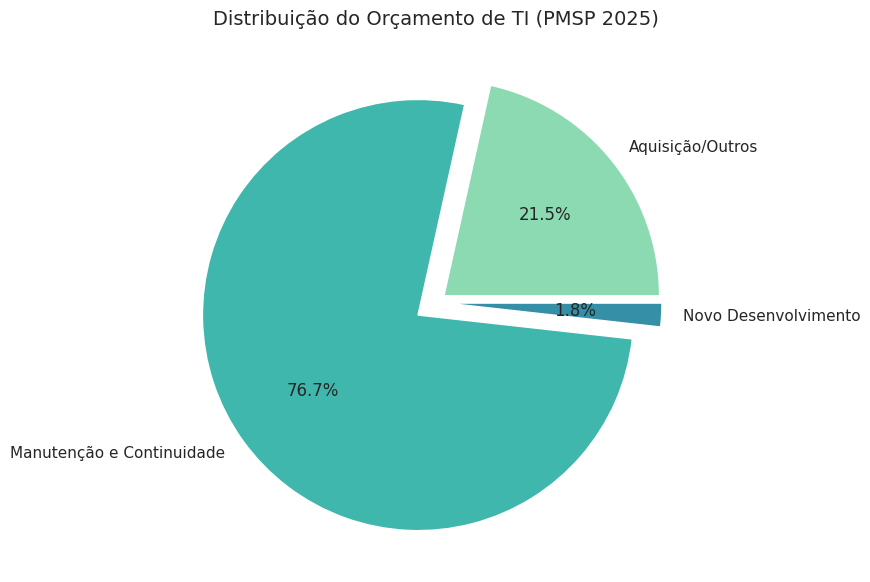

In [ ]:
#gerando visualizações
plt.figure(figsize=(10, 7))
cores = sns.color_palette('mako_r')
plt.pie(categorizacao, labels=categorizacao.index, autopct='%1.1f%%', colors = cores, explode=(0.05, 0.1, 0.05))
plt.title('Distribuição do Orçamento de TI (PMSP 2025)', fontsize=14)
plt.show()

**Achado principal:** 76,7% do orçamento de TI da PMSP em 2025 foi destinado a atividades de **manutenção e continuidade** de sistemas já existentes, enquanto apenas 1,8% foi direcionado a **novos desenvolvimentos** a partir do zero. Isso indica que, na prática orçamentária, a prioridade da gestão pública não é criar novas ferramentas constantemente, mas manter e evoluir o que já existe. Esse dado reforça diretamente a viabilidade estratégica de propor a **continuidade** de um sistema já em operação, em vez de sua substituição.

Para a análise, também pode ser interessante verificar as atividades e projetos que receberam maior orçamento.
São 10 valores unicos ao total, mas vamos limitar aos 5 primeiros (com maior orçamento)

In [ ]:
'''agrupando os dados pelo projeto/atividade, e somando os valores de orçamento atualizado.
Para cada atividade, organiza do maior para o menor e pega os 5 primeiros'''
top_5 = df.groupby('Ds_Projeto_Atividade')['Vl_Orcado_Atualizado'].sum().sort_values(ascending=False).head(5).reset_index()
top_5

,Ds_Projeto_Atividade,Vl_Orcado_Atualizado
0,Manutenção e Operação de Sistemas de Informaçã...,1.094514e+09
1,"Aquisição de Materiais, Equipamentos e Serviço...",3.342767e+08
2,Manutenção e Operação de Redes de Monitorament...,1.111044e+08
3,Desenvolvimento de Sistemas de Informação e Co...,2.787681e+07
4,Manutenção e Operação do Descomplica SP,1.245851e+07


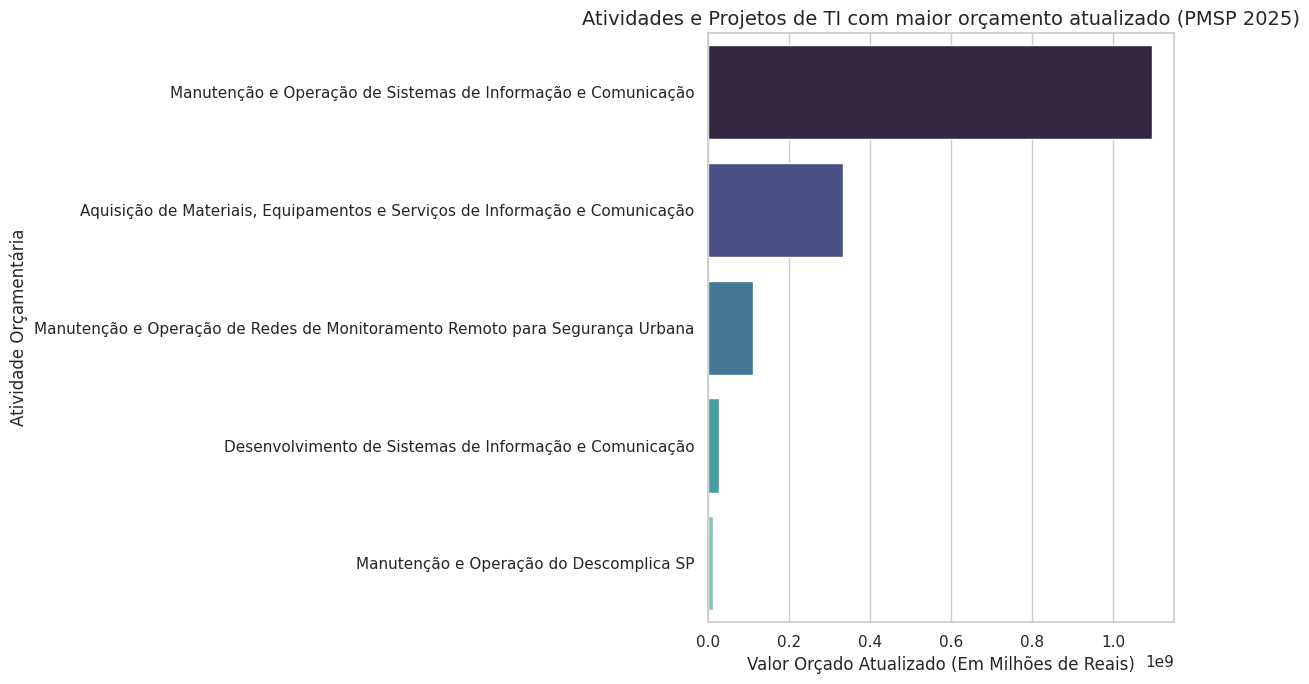

In [ ]:
#gerando a visualização

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=top_5, y='Ds_Projeto_Atividade', x='Vl_Orcado_Atualizado', palette='mako', hue='Ds_Projeto_Atividade')
plt.title('Atividades e Projetos de TI com maior orçamento atualizado (PMSP 2025)', fontsize=14)
plt.xlabel('Valor Orçado Atualizado (Em Milhões de Reais)')
plt.ylabel('Atividade Orçamentária')
plt.tight_layout()
plt.show()

## Conclusões

A análise combinada dessas duas fontes de dados sustenta dois pontos centrais:

1. **Há um déficit real e desigual de governança formal de TI** entre municípios brasileiros, o que reforça a importância de instrumentos (como um portal centralizado) que documentem processos e retirem conhecimento técnico crítico da dependência de pessoas específicas.
2. **A alocação orçamentária de uma grande prefeitura já prioriza manutenção sobre criação**, o que indica que dar continuidade a uma solução existente está alinhado à própria lógica de investimento da administração pública.

Essas conclusões foram usadas como fundamentação de dados para a proposta apresentada pelo grupo no relatório final do Projeto Integrador.

---
*Esta análise foi conduzida integralmente por mim (coleta, tratamento, categorização e visualização dos dados). O recorte do relatório final que inclui a fundamentação teórica utilizada para apoiar a análise pode ser consultado [aqui](./relatorio_analise_dados.pdf).*